# U-Net Instance Segmentation — Solar Panel Detection (`hassolar`)

Trains a U-Net on the CVAT/COCO-format solar-panel annotations (`merged_instances_default.json`) by rasterizing the polygon annotations into pixel masks, then derives per-instance predictions via connected-component post-processing so detection-style metrics (mAP@50, mAP@95) can be reported alongside standard pixel metrics.



In [37]:
import os
import json
import glob
import time
import csv
import random
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt

os.environ["CUDA_VISIBLE_DEVICES"] = "0"


In [14]:
print("✅ Imports successful")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not detected")

✅ Imports successful
PyTorch version: 2.14.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 2050


In [14]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [15]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [34]:
BASE_DIR = r"D:\SolarMap-India"

DATA_DIR = os.path.join(
    BASE_DIR,
    "dataset",
    "Solar Images",
    "Solar Images"
)

IMAGES_DIR = os.path.join(
    DATA_DIR,
    "images",
    "default"
)

ANNOTATIONS_JSON = os.path.join(
    DATA_DIR,
    "annotations",
    "merged_instances_default.json"
)

print("IMAGES_DIR:", IMAGES_DIR)
print("ANNOTATIONS_JSON:", ANNOTATIONS_JSON)
print("Images folder exists:", os.path.isdir(IMAGES_DIR))
print("Annotation file exists:", os.path.isfile(ANNOTATIONS_JSON))

IMAGES_DIR: D:\SolarMap-India\dataset\Solar Images\Solar Images\images\default
ANNOTATIONS_JSON: D:\SolarMap-India\dataset\Solar Images\Solar Images\annotations\merged_instances_default.json
Images folder exists: True
Annotation file exists: True


## Config — edit paths here

In [39]:
# =========================================================
# CONFIG — SolarMap-India
# =========================================================

PROJECT_ROOT = r"D:\SolarMap-India"

IMAGES_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "Solar Images",
    "Solar Images",
    "images",
    "default"
)

ANNOTATIONS_JSON = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "Solar Images",
    "Solar Images",
    "annotations",
    "merged_instances_default.json"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "FCN"
)

MODEL_SAVE_DIR = os.path.join(OUTPUT_DIR, "models")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, "predictions")

for d in [MODEL_SAVE_DIR, METRICS_DIR, PLOTS_DIR, PREDICTIONS_DIR]:
    os.makedirs(d, exist_ok=True)

IMG_SIZE = 256
NUM_CLASSES = 2
CLASS_NAMES = ["background", "hassolar"]
FOREGROUND_CLASS = 1
IGNORE_INDEX = None

BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 50

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
SEED = 42

PROB_THRESHOLD = 0.5
MIN_INSTANCE_AREA = 8
IOU_THRESHOLDS = (0.50, 0.95)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------
# Verify paths
# ---------------------------------------------------------

if not os.path.isfile(ANNOTATIONS_JSON):
    raise FileNotFoundError(
        f"Could not find annotation json at: {ANNOTATIONS_JSON}"
    )

if not os.path.isdir(IMAGES_DIR):
    raise FileNotFoundError(
        f"Could not find images directory at: {IMAGES_DIR}"
    )

print("Device:", DEVICE)
print("Images dir:", IMAGES_DIR)
print("Annotations json:", ANNOTATIONS_JSON)
print("Images folder exists:", os.path.isdir(IMAGES_DIR))
print("Annotation exists:", os.path.isfile(ANNOTATIONS_JSON))
print("Outputs:", OUTPUT_DIR)

Device: cuda
Images dir: D:\SolarMap-India\dataset\Solar Images\Solar Images\images\default
Annotations json: D:\SolarMap-India\dataset\Solar Images\Solar Images\annotations\merged_instances_default.json
Images folder exists: True
Annotation exists: True
Outputs: D:\SolarMap-India\outputs\FCN


## Load COCO annotations & build the train / val / test split

In [40]:
with open(ANNOTATIONS_JSON, "r") as f:
    coco = json.load(f)

categories = {c["id"]: c["name"] for c in coco["categories"]}
print("Categories:", categories)

images_by_id = {img["id"]: img for img in coco["images"]}

annotations_by_image = {}
for ann in coco["annotations"]:
    annotations_by_image.setdefault(ann["image_id"], []).append(ann)

print(f"Total images in json: {len(images_by_id)}")
print(f"Total annotations in json: {len(coco['annotations'])}")
print(f"Images with at least one annotation: {len(annotations_by_image)}")

# Keep only images that actually exist on disk
valid_image_ids = []
missing = 0
for image_id, entry in images_by_id.items():
    if os.path.isfile(os.path.join(IMAGES_DIR, entry["file_name"])):
        valid_image_ids.append(image_id)
    else:
        missing += 1
if missing:
    print(f"Warning: {missing} images listed in the json were not found in {IMAGES_DIR} and will be skipped.")
print(f"Usable images: {len(valid_image_ids)}")


Categories: {1: 'hassolar'}
Total images in json: 2500
Total annotations in json: 32825
Images with at least one annotation: 2492
Usable images: 2500


In [41]:
rng = random.Random(SEED)
shuffled_ids = valid_image_ids[:]
rng.shuffle(shuffled_ids)

n_total = len(shuffled_ids)
n_train = int(n_total * TRAIN_FRAC)
n_val = int(n_total * VAL_FRAC)

train_ids = shuffled_ids[:n_train]
val_ids = shuffled_ids[n_train:n_train + n_val]
test_ids = shuffled_ids[n_train + n_val:]

print(f"Train: {len(train_ids)}  Val: {len(val_ids)}  Test: {len(test_ids)}")

split_path = os.path.join(METRICS_DIR, "split_image_ids.json")
with open(split_path, "w") as f:
    json.dump({"train": train_ids, "val": val_ids, "test": test_ids}, f)

print(f"Saved split to {split_path}")

Train: 1750  Val: 375  Test: 375
Saved split to D:\SolarMap-India\outputs\FCN\metrics\split_image_ids.json


## Mask utilities (COCO polygon → raster mask)

In [42]:
def polygons_to_mask(segmentations, height, width):
    """Rasterize a list of COCO polygons (each a flat [x1,y1,x2,y2,...] list) into a binary mask."""
    mask_img = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask_img)
    for poly in segmentations:
        if len(poly) < 6:
            continue
        xy = list(zip(poly[0::2], poly[1::2]))
        draw.polygon(xy, outline=1, fill=1)
    return np.array(mask_img, dtype=np.uint8)


def semantic_mask_for_image(image_entry, anns):
    """Combined binary mask (all instances merged) at the image's original resolution."""
    h, w = image_entry["height"], image_entry["width"]
    mask = np.zeros((h, w), dtype=np.uint8)
    for ann in anns:
        seg = ann.get("segmentation", [])
        if not seg or ann.get("iscrowd", 0) == 1:
            continue
        inst_mask = polygons_to_mask(seg, h, w)
        mask = np.maximum(mask, inst_mask)
    return mask


def instance_masks_for_image(image_entry, anns, out_size):
    """Individual (resized) boolean instance masks — used only for instance-level evaluation."""
    h, w = image_entry["height"], image_entry["width"]
    masks = []
    for ann in anns:
        seg = ann.get("segmentation", [])
        if not seg or ann.get("iscrowd", 0) == 1:
            continue
        inst_mask = polygons_to_mask(seg, h, w)
        if inst_mask.sum() == 0:
            continue
        resized = np.array(
            Image.fromarray(inst_mask * 255).resize((out_size, out_size), resample=Image.NEAREST)
        ) > 127
        masks.append(resized)
    return masks


## Dataset

In [43]:
class SolarPanelDataset(Dataset):
    def __init__(self, image_ids, images_by_id, annotations_by_image, images_dir, img_size=256):
        self.image_ids = image_ids
        self.images_by_id = images_by_id
        self.annotations_by_image = annotations_by_image
        self.images_dir = images_dir
        self.img_size = img_size

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        entry = self.images_by_id[image_id]
        anns = self.annotations_by_image.get(image_id, [])

        image_path = os.path.join(self.images_dir, entry["file_name"])
        image = Image.open(image_path).convert("RGB")
        image = self.img_transform(image)

        mask = semantic_mask_for_image(entry, anns)
        mask_img = Image.fromarray(mask * 255)
        mask_img = mask_img.resize((self.img_size, self.img_size), resample=Image.NEAREST)
        mask = (np.array(mask_img) > 127).astype(np.int64)
        mask = torch.from_numpy(mask)

        return image, mask, image_id


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.14.1+cu126
Device: cuda


## U-Net model

In [6]:
class FCN(nn.Module):
    def __init__(self, num_classes=2, in_channels=3, base_channels=32):
        super().__init__()

        c = base_channels

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.ReLU(inplace=True),

            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.ReLU(inplace=True)
        )

        self.enc2 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(c, c * 2, 3, padding=1),
            nn.BatchNorm2d(c * 2),
            nn.ReLU(inplace=True),

            nn.Conv2d(c * 2, c * 2, 3, padding=1),
            nn.BatchNorm2d(c * 2),
            nn.ReLU(inplace=True)
        )

        self.enc3 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(c * 2, c * 4, 3, padding=1),
            nn.BatchNorm2d(c * 4),
            nn.ReLU(inplace=True),

            nn.Conv2d(c * 4, c * 4, 3, padding=1),
            nn.BatchNorm2d(c * 4),
            nn.ReLU(inplace=True)
        )

        self.enc4 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(c * 4, c * 8, 3, padding=1),
            nn.BatchNorm2d(c * 8),
            nn.ReLU(inplace=True),

            nn.Conv2d(c * 8, c * 8, 3, padding=1),
            nn.BatchNorm2d(c * 8),
            nn.ReLU(inplace=True)
        )

        # Fully convolutional classifier
        self.classifier = nn.Sequential(
            nn.Conv2d(c * 8, c * 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5),

            nn.Conv2d(c * 16, num_classes, kernel_size=1)
        )

        # Upsampling
        self.up = nn.ConvTranspose2d(
            num_classes,
            num_classes,
            kernel_size=16,
            stride=8,
            padding=4
        )

    def forward(self, x):
        input_size = x.shape[2:]

        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)

        x = self.classifier(x)

        x = self.up(x)

        # Make sure output is exactly 256x256
        x = F.interpolate(
            x,
            size=input_size,
            mode="bilinear",
            align_corners=False
        )

        return x

## Losses & pixel-wise metrics

In [44]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        probs = torch.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_one_hot, dims)
        cardinality = torch.sum(probs + targets_one_hot, dims)
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice.mean()


class SegmentationMetrics:
    """Pixel-wise accuracy / precision / recall / F1 / IoU / Dice, averaged across classes."""
    def __init__(self, num_classes, ignore_index=None, eps=1e-7):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.eps = eps
        self.reset()

    def reset(self):
        self.tp = torch.zeros(self.num_classes, dtype=torch.float64)
        self.fp = torch.zeros(self.num_classes, dtype=torch.float64)
        self.fn = torch.zeros(self.num_classes, dtype=torch.float64)
        self.correct = 0
        self.total = 0

    def update(self, logits, targets):
        preds = torch.argmax(logits, dim=1)
        if self.ignore_index is not None:
            valid_mask = targets != self.ignore_index
            preds = preds[valid_mask]
            targets = targets[valid_mask]
        self.correct += (preds == targets).sum().item()
        self.total += targets.numel()
        for cls in range(self.num_classes):
            pred_cls = preds == cls
            target_cls = targets == cls
            self.tp[cls] += (pred_cls & target_cls).sum().item()
            self.fp[cls] += (pred_cls & ~target_cls).sum().item()
            self.fn[cls] += (~pred_cls & target_cls).sum().item()

    def compute(self):
        precision = self.tp / (self.tp + self.fp + self.eps)
        recall = self.tp / (self.tp + self.fn + self.eps)
        f1 = 2 * precision * recall / (precision + recall + self.eps)
        iou = self.tp / (self.tp + self.fp + self.fn + self.eps)
        dice = 2 * self.tp / (2 * self.tp + self.fp + self.fn + self.eps)
        accuracy = self.correct / max(self.total, 1)
        return {
            "accuracy": float(accuracy),
            "precision": float(precision.mean()),
            "recall": float(recall.mean()),
            "f1": float(f1.mean()),
            "iou": float(iou.mean()),
            "dice": float(dice.mean()),
            "dice_loss": float(1.0 - dice.mean()),
        }


model = FCN(num_classes=NUM_CLASSES, in_channels=3, base_channels=32).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 2,356,388


In [25]:
import time

print("Testing one batch...")

start = time.time()
images, masks, image_ids = next(iter(train_loader))

print(f"Batch loaded in {time.time() - start:.2f} seconds")
print("Images:", images.shape)
print("Masks:", masks.shape)

images = images.to(DEVICE)
masks = masks.to(DEVICE)

torch.cuda.synchronize()
start = time.time()

with torch.no_grad():
    outputs = model(images)

torch.cuda.synchronize()

print(f"Forward pass: {time.time() - start:.2f} seconds")
print("Output:", outputs.shape)
print("Output device:", outputs.device)
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.1f} MB")

Testing one batch...
Batch loaded in 0.33 seconds
Images: torch.Size([8, 3, 256, 256])
Masks: torch.Size([8, 256, 256])
Forward pass: 1.13 seconds
Output: torch.Size([8, 2, 256, 256])
Output device: cuda:0
GPU memory: 23.3 MB


In [ ]:
def mask_iou(mask_a, mask_b):
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return float(inter) / float(union) if union > 0 else 0.0


def extract_predicted_instances(prob_map, prob_threshold=0.5, min_area=8):
    """Turn a per-pixel foreground probability map into candidate instances via connected components."""
    binary = (prob_map >= prob_threshold).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(binary, connectivity=8)
    instances = []
    for lbl in range(1, num_labels):
        inst_mask = labels == lbl
        area = int(inst_mask.sum())
        if area < min_area:
            continue
        score = float(prob_map[inst_mask].mean())
        instances.append({"mask": inst_mask, "score": score})
    return instances


def _ap_from_pr(recalls, precisions):
    """Area under the precision-recall curve (VOC/COCO-style monotonic envelope)."""
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


def evaluate_instances(model, image_ids, images_by_id, annotations_by_image, images_dir,
                        img_size, device, iou_thresholds=(0.5, 0.95),
                        prob_threshold=0.5, min_area=8):
    """
    Runs the model over `image_ids`, extracts predicted instances via connected components,
    matches them to ground-truth polygon instances by mask IoU, and returns:
      - mAP at each IoU threshold in `iou_thresholds` (keys "map_50", "map_95", ...)
      - instance-level precision / recall / F1 at IoU 0.5 (single operating point)
    """
    model.eval()
    predictions = []          # list of {"image_id", "score", "mask"}
    gts_by_image = {}
    gt_total = 0

    img_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

    with torch.no_grad():
        for image_id in image_ids:
            entry = images_by_id[image_id]
            anns = annotations_by_image.get(image_id, [])

            image = Image.open(os.path.join(images_dir, entry["file_name"])).convert("RGB")
            image_t = img_transform(image).unsqueeze(0).to(device)

            logits = model(image_t)
            probs = torch.softmax(logits, dim=1)[0, FOREGROUND_CLASS].cpu().numpy()

            preds = extract_predicted_instances(probs, prob_threshold=prob_threshold, min_area=min_area)
            for p in preds:
                predictions.append({"image_id": image_id, "score": p["score"], "mask": p["mask"]})

            gt_masks = instance_masks_for_image(entry, anns, img_size)
            gts_by_image[image_id] = gt_masks
            gt_total += len(gt_masks)

    results = {}
    preds_sorted = sorted(predictions, key=lambda x: -x["score"])

    for thr in iou_thresholds:
        matched = {img_id: [False] * len(gts) for img_id, gts in gts_by_image.items()}
        tp = np.zeros(len(preds_sorted))
        fp = np.zeros(len(preds_sorted))
        for i, p in enumerate(preds_sorted):
            gts = gts_by_image.get(p["image_id"], [])
            best_iou, best_j = 0.0, -1
            for j, gt_mask in enumerate(gts):
                if matched[p["image_id"]][j]:
                    continue
                iou = mask_iou(p["mask"], gt_mask)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou >= thr:
                tp[i] = 1
                matched[p["image_id"]][best_j] = True
            else:
                fp[i] = 1

        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        recalls = tp_cum / max(gt_total, 1)
        precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-9)
        ap = _ap_from_pr(recalls, precisions)
        results[f"map_{int(round(thr * 100))}"] = ap

        if abs(thr - 0.5) < 1e-6:
            total_tp = float(tp.sum())
            total_fp = float(fp.sum())
            total_fn = float(gt_total - total_tp)
            eps = 1e-7
            precision = total_tp / (total_tp + total_fp + eps)
            recall = total_tp / (total_tp + total_fn + eps)
            f1 = 2 * precision * recall / (precision + recall + eps)
            results["instance_precision"] = precision
            results["instance_recall"] = recall
            results["instance_f1"] = f1

    results["num_predicted_instances"] = len(preds_sorted)
    results["num_gt_instances"] = gt_total
    return results


## DataLoaders

In [46]:
num_workers = 0

train_dataset = SolarPanelDataset(train_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)
val_dataset = SolarPanelDataset(val_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)
test_dataset = SolarPanelDataset(test_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)

def collate_fn(batch):
    images = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    image_ids = [b[2] for b in batch]
    return images, masks, image_ids

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                           collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                         collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                          collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 1750
Val samples: 375
Test samples: 375


## Training utilities (pixel-level metrics, run every epoch)

In [19]:
def format_metrics(prefix, metrics):
    return (
        f"{prefix} acc={metrics['accuracy']:.4f} "
        f"prec={metrics['precision']:.4f} recall={metrics['recall']:.4f} "
        f"f1={metrics['f1']:.4f} dice={metrics['dice']:.4f} "
        f"iou={metrics['iou']:.4f} dice_loss={metrics['dice_loss']:.4f}"
    )


def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    metrics = SegmentationMetrics(NUM_CLASSES, ignore_index=IGNORE_INDEX)
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for images, masks, _image_ids in loader:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            if is_train:
                optimizer.zero_grad()
            logits = model(images)
            loss_ce = criterion_ce(logits, masks)
            loss_dice = criterion_dice(logits, masks)
            loss = loss_ce + loss_dice
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            metrics.update(logits, masks)
    avg_loss = total_loss / max(len(loader.dataset), 1)
    return avg_loss, metrics.compute()


## Training loop

In [18]:
history = {"train_loss": [], "val_loss": [], "train_metrics": [], "val_metrics": []}
best_val_loss = float("inf")
best_model_path = os.path.join(MODEL_SAVE_DIR, "fcn_best.pth")
train_metrics_path = os.path.join(METRICS_DIR, "metrics_train_val_per_epoch.csv")

train_start = time.time()
print("Training start:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_start)))

with open(train_metrics_path, "w", newline="") as metrics_file:
    writer = csv.writer(metrics_file)
    writer.writerow(["epoch", "split", "loss", "accuracy", "precision", "recall", "f1", "dice", "iou", "dice_loss"])

    for epoch in range(EPOCHS):
        epoch_start = time.time()
        train_loss, train_metrics = run_epoch(train_loader, model, optimizer=optimizer)
        val_loss, val_metrics = run_epoch(val_loader, model, optimizer=None)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_metrics"].append(train_metrics)
        history["val_metrics"].append(val_metrics)

        for split_name, loss_val, m in [("train", train_loss, train_metrics), ("val", val_loss, val_metrics)]:
            writer.writerow([epoch + 1, split_name, loss_val, m["accuracy"], m["precision"],
                              m["recall"], m["f1"], m["dice"], m["iou"], m["dice_loss"]])
        metrics_file.flush()

        print(f"Epoch {epoch + 1}/{EPOCHS} | train_loss={train_loss:.4f} val_loss={val_loss:.4f}")
        print(format_metrics("Train", train_metrics))
        print(format_metrics("Val  ", val_metrics))
        print(f"Epoch time: {time.time() - epoch_start:.1f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
            }, best_model_path)
            print(f"Saved best model: {best_model_path}")

train_end = time.time()
print("Training end:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_end)))
print(f"Total training time: {train_end - train_start:.1f}s")
print(f"Per-epoch train/val metrics saved to {train_metrics_path}")


Training start: 2026-10-07 18:54:40


NameError: name 'run_epoch' is not defined

In [ ]:
print("DEVICE:", DEVICE)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

print("Model device:", next(model.parameters()).device)

## Training curves

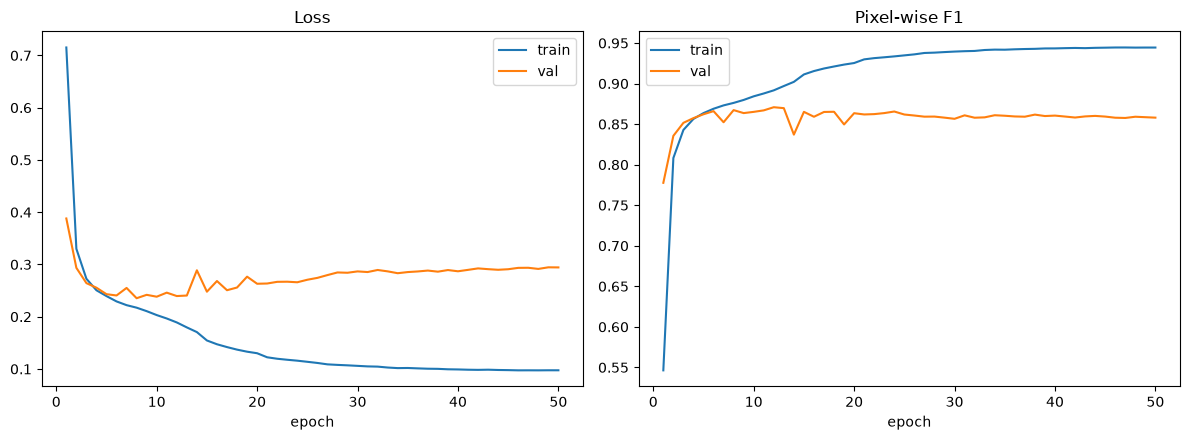

Saved training curves to D:\SolarMap-India\outputs\FCN\plots\training_curves.png


In [28]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

train_f1 = [m["f1"] for m in history["train_metrics"]]
val_f1 = [m["f1"] for m in history["val_metrics"]]
axes[1].plot(epochs_range, train_f1, label="train")
axes[1].plot(epochs_range, val_f1, label="val")
axes[1].set_title("Pixel-wise F1")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
curve_path = os.path.join(PLOTS_DIR, "training_curves.png")
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Saved training curves to {curve_path}")


## Final metrics: pixel + instance (mAP) for train / val / test

In [21]:
if os.path.isfile(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model from {best_model_path} (epoch {checkpoint['epoch']})")

split_loaders = {"train": (train_loader, train_ids), "val": (val_loader, val_ids), "test": (test_loader, test_ids)}
summary_rows = []

for split_name, (loader, ids) in split_loaders.items():
    loss, pixel_metrics = run_epoch(loader, model, optimizer=None)
    inst_metrics = evaluate_instances(
        model, ids, images_by_id, annotations_by_image, IMAGES_DIR, IMG_SIZE, DEVICE,
        iou_thresholds=IOU_THRESHOLDS, prob_threshold=PROB_THRESHOLD, min_area=MIN_INSTANCE_AREA,
    )

    row = {
        "split": split_name,
        "loss": loss,
        "pixel_accuracy": pixel_metrics["accuracy"],
        "pixel_precision": pixel_metrics["precision"],
        "pixel_recall": pixel_metrics["recall"],
        "pixel_f1": pixel_metrics["f1"],
        "pixel_dice": pixel_metrics["dice"],
        "pixel_iou": pixel_metrics["iou"],
        "instance_precision": inst_metrics.get("instance_precision", float("nan")),
        "instance_recall": inst_metrics.get("instance_recall", float("nan")),
        "instance_f1": inst_metrics.get("instance_f1", float("nan")),
        "map_50": inst_metrics.get("map_50", float("nan")),
        "map_95": inst_metrics.get("map_95", float("nan")),
        "num_gt_instances": inst_metrics["num_gt_instances"],
        "num_predicted_instances": inst_metrics["num_predicted_instances"],
    }
    summary_rows.append(row)

    print(f"\n===== {split_name.upper()} =====")
    print(f"loss={loss:.4f}")
    print(f"Pixel    -> acc={row['pixel_accuracy']:.4f} prec={row['pixel_precision']:.4f} "
          f"recall={row['pixel_recall']:.4f} f1={row['pixel_f1']:.4f}")
    print(f"Instance -> prec={row['instance_precision']:.4f} recall={row['instance_recall']:.4f} "
          f"f1={row['instance_f1']:.4f}")
    print(f"mAP@50={row['map_50']:.4f}  mAP@95={row['map_95']:.4f}")

summary_path = os.path.join(METRICS_DIR, "metrics_summary_train_val_test.csv")
fieldnames = list(summary_rows[0].keys())
with open(summary_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(summary_rows)

print(f"\nSaved full train/val/test metric summary to {summary_path}")


NameError: name 'train_loader' is not defined

## Save final model

In [30]:
final_model_path = os.path.join(MODEL_SAVE_DIR, "unet_final.pth")
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to {final_model_path}")


Final model saved to D:\SolarMap-India\outputs\FCN\models\unet_final.pth


## Sample prediction visualizations (saved to outputs/predictions)

In [31]:
def save_prediction_examples(model, image_ids, images_by_id, annotations_by_image, images_dir,
                              img_size, device, out_dir, num_examples=6):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()
    img_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    sample_ids = image_ids[:num_examples]
    with torch.no_grad():
        for image_id in sample_ids:
            entry = images_by_id[image_id]
            anns = annotations_by_image.get(image_id, [])
            image = Image.open(os.path.join(images_dir, entry["file_name"])).convert("RGB")
            image_t = img_transform(image).unsqueeze(0).to(device)
            logits = model(image_t)
            pred = torch.argmax(logits, dim=1)[0].cpu().numpy()

            gt_mask = semantic_mask_for_image(entry, anns)
            gt_mask = np.array(Image.fromarray(gt_mask * 255).resize((img_size, img_size), Image.NEAREST)) > 127

            input_disp = np.array(image.resize((img_size, img_size)))
            fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
            axes[0].imshow(input_disp); axes[0].set_title("Input"); axes[0].axis("off")
            axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("Ground truth"); axes[1].axis("off")
            axes[2].imshow(pred, cmap="gray"); axes[2].set_title("Prediction"); axes[2].axis("off")
            plt.tight_layout()
            out_path = os.path.join(out_dir, f"{entry['file_name'].rsplit('.', 1)[0]}_comparison.png")
            plt.savefig(out_path, dpi=130)
            plt.close(fig)

save_prediction_examples(model, test_ids, images_by_id, annotations_by_image, IMAGES_DIR,
                          IMG_SIZE, DEVICE, PREDICTIONS_DIR, num_examples=6)
print(f"Saved sample prediction comparisons to {PREDICTIONS_DIR}")


Saved sample prediction comparisons to D:\SolarMap-India\outputs\FCN\predictions


In [16]:
NUM_CLASSES = 2

print("NUM_CLASSES =", NUM_CLASSES)

NUM_CLASSES = 2


In [7]:
print("FCN class exists:", "FCN" in globals())
print("Device:", device if "device" in globals() else "Not defined")


FCN class exists: True
Device: cuda


In [47]:
# ============================================================
# FCN — TEST SET EVALUATION
# ============================================================

MODEL_PATH = r"D:\SolarMap-India\outputs\FCN\models\fcn_best.pth"

print("Model path:", MODEL_PATH)
print("Checkpoint exists:", os.path.exists(MODEL_PATH))

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

print("\nCheckpoint loaded!")
print("Checkpoint keys:", checkpoint.keys())

# ------------------------------------------------------------
# Create FCN model
# ------------------------------------------------------------
model = FCN(
    in_channels=3,
    num_classes=NUM_CLASSES
).to(device)

# Load weights
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("FCN loaded successfully!")
print("Device:", device)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------
test_loss, test_metrics = run_epoch(
    test_loader,
    model,
    optimizer=None
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("FCN — TEST SET RESULTS")
print("=" * 60)

print(f"Test Loss  : {test_loss:.4f}")
print(f"Accuracy   : {test_metrics['accuracy']:.4f}")
print(f"Precision  : {test_metrics['precision']:.4f}")
print(f"Recall     : {test_metrics['recall']:.4f}")
print(f"F1 Score   : {test_metrics['f1']:.4f}")
print(f"Dice Score : {test_metrics['dice']:.4f}")
print(f"IoU        : {test_metrics['iou']:.4f}")
print(f"Dice Loss  : {test_metrics['dice_loss']:.4f}")

print("=" * 60)

Model path: D:\SolarMap-India\outputs\FCN\models\fcn_best.pth
Checkpoint exists: True

Checkpoint loaded!
Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss'])
FCN loaded successfully!
Device: cuda

FCN — TEST SET RESULTS
Test Loss  : 0.2330
Accuracy   : 0.9745
Precision  : 0.8754
Recall     : 0.8599
F1 Score   : 0.8675
Dice Score : 0.8675
IoU        : 0.7857
Dice Loss  : 0.1325
